In [35]:
from dilated_nns_xors import output_dir, default_config
from misc_utils import read_jsonl_to_df, keep_serializable, concat_columns, column_to
import seaborn as sns
import torch
from conv2d_circular import EquivariantConv2d
import numpy.typing as npt
import numpy as np
from spin_lattices import SquareLattice

In [38]:
df = (
    read_jsonl_to_df(output_dir.glob("*/results.jsonl"))
    .fillna(keep_serializable(default_config))
)

In [42]:
df.query('lattice == "square5x5" and xor_num_terms == 1').assign(
    n_channels=lambda x: x["hidden_channels"].apply(len)
)['n_channels']

8000      3
8001      3
8002      3
8003      3
8004      3
         ..
147995    3
147996    3
147997    3
147998    3
147999    3
Name: n_channels, Length: 76000, dtype: int64

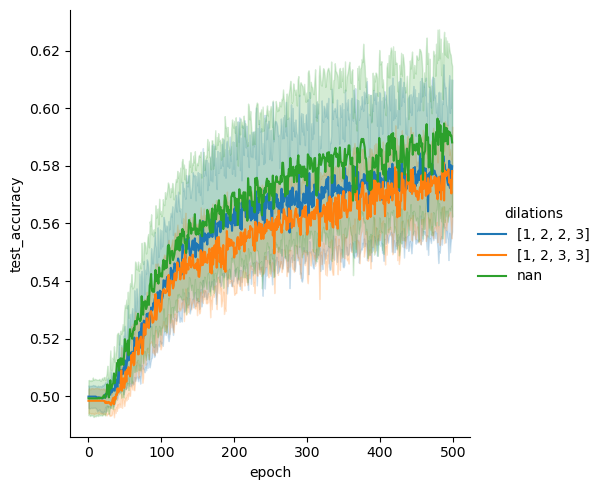

In [44]:
sns.relplot(
    df.query('lattice == "square5x5" and xor_num_terms == 1')
    .assign(n_channels=lambda x: x["hidden_channels"].apply(len))
    .pipe(column_to(str, "dilations")).query("n_channels == 4"),
    x="epoch",
    y="test_accuracy",
    hue="dilations",
    kind="line",
)

In [7]:
df['xor_num_ones'].unique()

array([7])

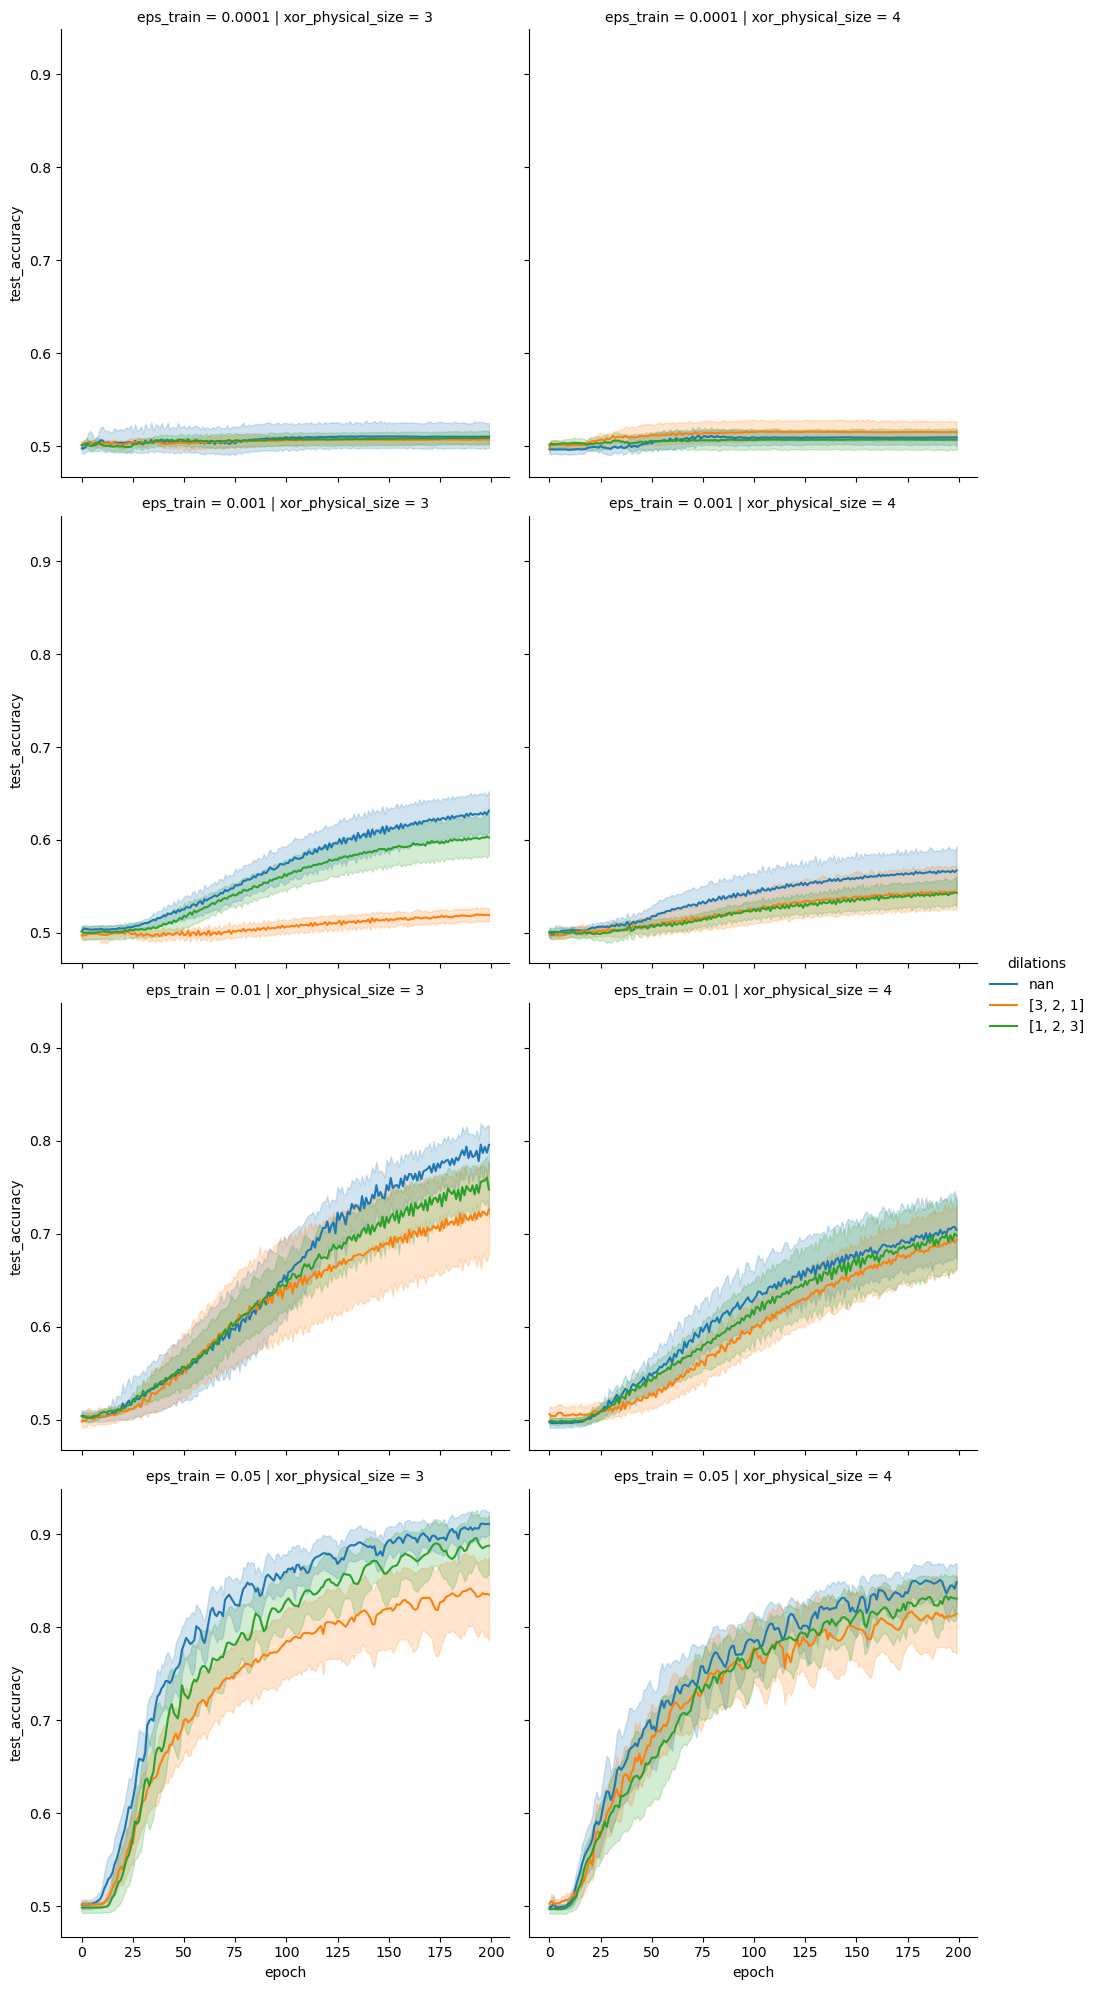

In [19]:
sns.relplot(
    df.query(
        'lattice == "square6x4"'
    ).pipe(column_to(str, 'dilations')),
    x="epoch",
    y="test_accuracy",
    hue="dilations",
    kind='line',
    col='xor_physical_size',
    row='eps_train',
)

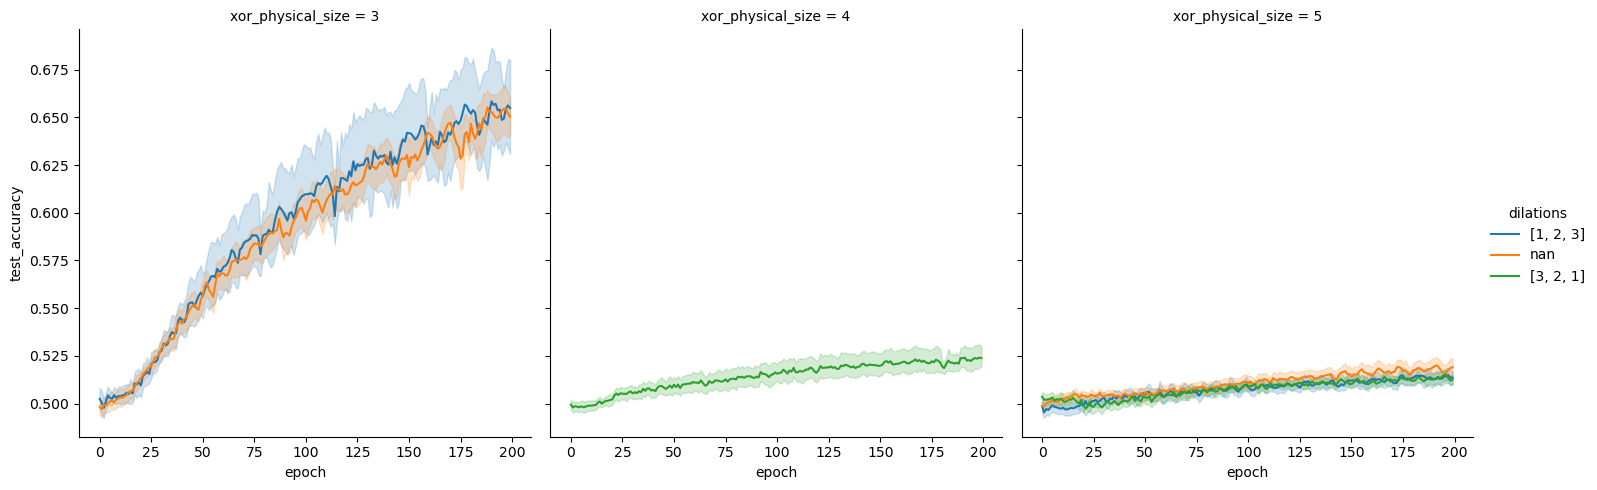

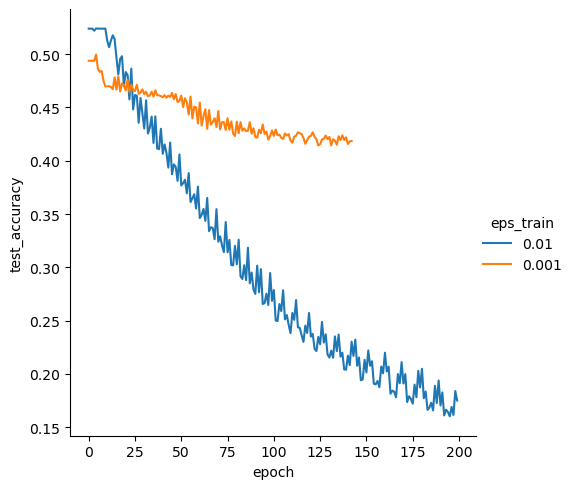

In [22]:
sns.relplot(
    df.pipe(column_to(str, "eps_train")),
    x="epoch",
    y="test_accuracy",
    kind="line",
    hue="eps_train",
)

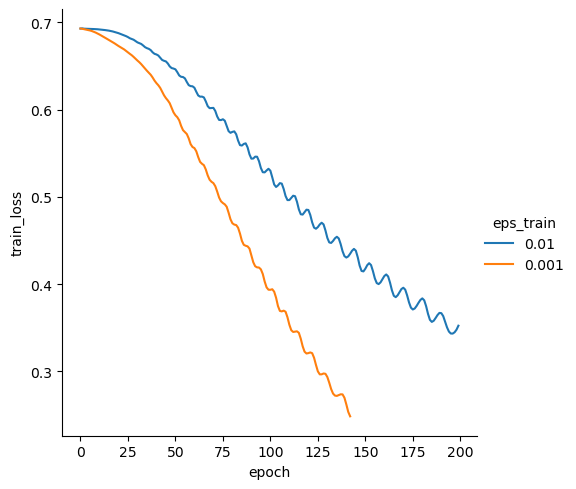

In [23]:
sns.relplot(
    df.pipe(column_to(str, "eps_train")),
    x="epoch",
    y="train_loss",
    kind="line",
    hue="eps_train",
)

In [4]:
lattice.num_tensor_order

array([ 0,  2,  4,  6,  1,  3,  5,  7,  8,  9, 10, 11, 12, 13, 14, 15])

In [5]:
spin_config_matrix_flat = np.array(
    [[1, 1, 0, 0], [1, 1, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]]
).reshape(-1)

In [6]:
lattice.num_tensor_order

array([ 0,  2,  4,  6,  1,  3,  5,  7,  8,  9, 10, 11, 12, 13, 14, 15])

In [7]:
spin_config = np.zeros(16)
spin_config[lattice.num_tensor_order] = spin_config_matrix_flat

<Axes: xlabel='emb_x', ylabel='emb_y'>

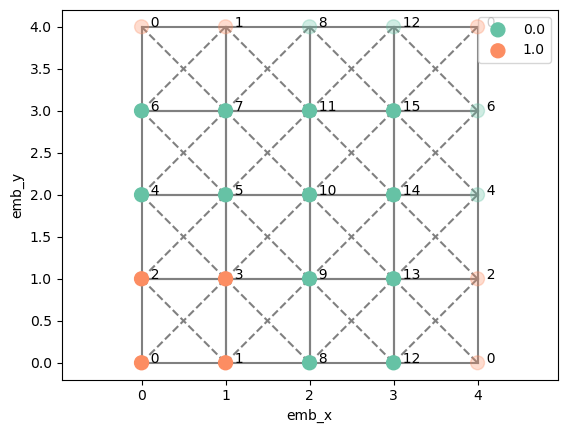

In [8]:
lattice.plot(spins=spin_config)

In [11]:
# visualize_coeffs(
#     make_random_fourier_series(
#         lattice, 3, 4, np.array([1.0, 2.0, 3.0]), make_symmetric=True
#     ),
#     40,
#     lattice,
# )

In [33]:
system = HeisenbergJ1J2(lattice, use_symmetries=True, skip_symmetries_whitelist=True, hamming_weight=None)

2024-02-06 21:01:04.718 | DEBUG    | heisenberg_hamiltonians:__init__:526 - number_spins=16
2024-02-06 21:01:04.750 | DEBUG    | heisenberg_hamiltonians:__init__:541 - Symmetry group contains 128 elements
2024-02-06 21:01:04.751 | DEBUG    | heisenberg_hamiltonians:__init__:542 - Constructing basis
2024-02-06 21:01:04.826 | DEBUG    | heisenberg_hamiltonians:__init__:550 - Hilbert space dimension is 805


In [34]:
eps_train = 0.1
n_train = int(system.basis.number_states * eps_train)
n_test = 100
train_states, test_states = mk_train_test(system, n_train, n_test, sampling_power_train=0, sampling_power_test=0)

2024-02-06 21:01:07.382 | DEBUG    | fourier_supervised_cleanroom:mk_train_test:256 - Sampling train
2024-02-06 21:01:07.383 | DEBUG    | fourier_supervised_cleanroom:sample_from_system:130 - Finding probs
2024-02-06 21:01:07.384 | DEBUG    | fourier_supervised_cleanroom:sample_from_system:141 - Doing np.random.choice
2024-02-06 21:01:07.385 | DEBUG    | fourier_supervised_cleanroom:mk_train_test:263 - Finding rest states
2024-02-06 21:01:07.386 | DEBUG    | fourier_supervised_cleanroom:mk_train_test:269 - Sampling test
2024-02-06 21:01:07.386 | DEBUG    | fourier_supervised_cleanroom:sample_from_system:130 - Finding probs
2024-02-06 21:01:07.386 | DEBUG    | fourier_supervised_cleanroom:sample_from_system:141 - Doing np.random.choice


In [55]:
physical_size = 2
num_ones = 1
n_coeffs = 1
coeffs = np.random.uniform(-1, 1, size=n_coeffs)
series = make_random_fourier_series(
    lattice,
    physical_size=physical_size,
    num_ones=num_ones,
    coeffs=coeffs,
    make_symmetric=True,
)

In [56]:
series(train_states)

array([-8.88178420e-16,  2.01034092e+01, -6.70113638e+00, -1.77635684e-15,
       -3.35056819e+01,  2.01034092e+01, -4.02068183e+01, -3.35056819e+01,
       -2.22044605e-16, -2.01034092e+01, -4.44089210e-16,  0.00000000e+00,
       -6.70113638e+00, -1.34022728e+01,  4.44089210e-16, -2.01034092e+01,
        1.34022728e+01, -2.01034092e+01, -1.34022728e+01, -2.01034092e+01,
       -2.01034092e+01, -2.22044605e-16, -6.70113638e+00,  6.70113638e+00,
       -1.34022728e+01, -2.68045455e+01, -1.34022728e+01,  0.00000000e+00,
       -2.68045455e+01,  2.22044605e-16,  6.70113638e+00,  6.70113638e+00,
       -1.34022728e+01,  0.00000000e+00, -1.34022728e+01,  2.68045455e+01,
        6.70113638e+00, -6.70113638e+00, -1.34022728e+01, -4.44089210e-16,
        2.68045455e+01, -2.01034092e+01,  6.70113638e+00,  8.88178420e-16,
       -4.44089210e-16, -1.34022728e+01, -6.70113638e+00, -2.01034092e+01,
        6.70113638e+00,  0.00000000e+00, -2.01034092e+01, -2.22044605e-16,
       -6.70113638e+00, -

In [63]:
target = thresholded_sign(series(train_states), tol=1e-14)

In [68]:
dataset = SpinDataset(
    torch.tensor(train_states.astype(np.int64), dtype=torch.int64),
    torch.tensor(target),
    batch_size=64,
)

In [ ]:
network = InvariantSpinCNNRegression(
    lattice,
    
)